# Model - Logistic Regression (Member 1)

**Role in the project:** interpretable baseline that every other model must beat.

**Optimisation topic:** threshold tuning (is 0.5 the right cut-off?).

**Validation:** chronological hold-out (last 20% of rows = test set, as promised in the dataset proposal), stratified 5-fold CV on the training part only. The test set is used once, at the end. `duration` is excluded (leakage). All preprocessing is inside one pipeline, so it is fitted on training folds only.

## 0. Setup

In [1]:
import sys, csv, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve,
                             precision_score, recall_score, f1_score, confusion_matrix)

sys.path.append(str(Path.cwd().parent))
from src.config import RANDOM_STATE, CV_FOLDS, ROOT, EXPERIMENT_LOG
from src.lr_model import load_data, chronological_split, build_lr_pipeline

FIG_DIR = ROOT / "results" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR = ROOT / "models" / "experiments"; MODEL_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")


def save_fig(name):
    plt.tight_layout(); plt.savefig(FIG_DIR / f"lr_{name}.png", dpi=150, bbox_inches="tight")

## 1. Data and chronological split

In [2]:
X, y = load_data()                       # duration dropped, exact duplicates removed, date order kept
X_train, X_test, y_train, y_test = chronological_split(X, y, test_fraction=0.20)

print(f"Rows after removing duplicates: {len(X):,}")
print(f"Train: {len(X_train):,} rows, yes-rate {y_train.mean():.2%}")
print(f"Test : {len(X_test):,} rows, yes-rate {y_test.mean():.2%}")
print(f"Imbalance ratio (no:yes) in train: {(1 - y_train.mean()) / y_train.mean():.1f} : 1")

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)   # same folds for every model
SCORING = {"pr_auc": "average_precision", "roc_auc": "roc_auc", "recall": "recall", "precision": "precision", "f1": "f1"}


def cv_summary(pipe):
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=1)
    return {k: (r[f"test_{k}"].mean(), r[f"test_{k}"].std()) for k in SCORING}

Rows after removing duplicates: 39,404
Train: 31,523 rows, yes-rate 6.61%
Test : 7,881 rows, yes-rate 31.90%
Imbalance ratio (no:yes) in train: 14.1 : 1


### Insight -> decision (split)

*(Fill in with your own numbers.)*

- Finding: 
- Decision: 
- Reason / alternative rejected: 

## 2. Client-feature decisions (evidence for PE1)

Same model and folds, only one preprocessing choice changes at a time. Metric: CV PR-AUC (main metric because of the imbalance).

In [3]:
variants = {
    "unknown = own category, with age_group (default)": dict(unknown_strategy="category", use_age_group=True),
    "unknown = mode imputation, with age_group":         dict(unknown_strategy="mode",     use_age_group=True),
    "unknown = own category, WITHOUT age_group":         dict(unknown_strategy="category", use_age_group=False),
}
rows = []
for name, kw in variants.items():
    s = cv_summary(build_lr_pipeline(C=1.0, **kw))
    rows.append({"variant": name, "cv_pr_auc_mean": s["pr_auc"][0], "cv_pr_auc_std": s["pr_auc"][1],
                 "cv_roc_auc_mean": s["roc_auc"][0]})
experiment = pd.DataFrame(rows).set_index("variant")
print(experiment)

                                                  cv_pr_auc_mean  \
variant                                                            
unknown = own category, with age_group (default)          0.2036   
unknown = mode imputation, with age_group                 0.2042   
unknown = own category, WITHOUT age_group                 0.2022   

                                                  cv_pr_auc_std  \
variant                                                           
unknown = own category, with age_group (default)         0.0183   
unknown = mode imputation, with age_group                0.0182   
unknown = own category, WITHOUT age_group                0.0168   

                                                  cv_roc_auc_mean  
variant                                                            
unknown = own category, with age_group (default)           0.6747  
unknown = mode imputation, with age_group                  0.6752  
unknown = own category, WITHOUT age_group          

### Insight -> decision (keep 'unknown' as a category? keep age_group?)

*(Fill in with your own numbers.)*

- Finding: 
- Decision: 
- Reason / alternative rejected: 

*Tip for the viva: if the differences are smaller than the standard deviation, say so - the choice is then made on simplicity and interpretability, not on a tiny score gap.*

## 3. Baseline Logistic Regression

`class_weight='balanced'`, default `C=1`, L2 penalty, scaled numerics, one-hot categoricals.

In [4]:
baseline = build_lr_pipeline(C=1.0, l1_ratio=0.0)
base_cv = cv_summary(baseline)
print("Baseline 5-fold CV (mean +/- std):")
for k, (m, s) in base_cv.items():
    print(f"  {k:10s} {m:.4f} +/- {s:.4f}")

Baseline 5-fold CV (mean +/- std):
  pr_auc     0.2036 +/- 0.0183
  roc_auc    0.6747 +/- 0.0122
  recall     0.5163 +/- 0.0252
  precision  0.1182 +/- 0.0058
  f1         0.1923 +/- 0.0086


### Insight -> decision (baseline)

*(Fill in with your own numbers.)*

- Finding: 
- Decision: 
- Reason / alternative rejected: 

## 4. Hyperparameter tuning (GridSearchCV, scoring = average precision)

`C` = inverse regularisation strength (smaller = stronger regularisation). `l1_ratio` 0 = L2 penalty, 1 = L1 penalty.

In [5]:
param_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100], "clf__l1_ratio": [0.0, 1.0]}
grid = GridSearchCV(build_lr_pipeline(), param_grid, scoring="average_precision", cv=cv, n_jobs=1, refit=True)
grid.fit(X_train, y_train)

results = (pd.DataFrame(grid.cv_results_)[["param_clf__C", "param_clf__l1_ratio", "mean_test_score", "std_test_score"]]
           .rename(columns={"param_clf__C": "C", "param_clf__l1_ratio": "l1_ratio (0=L2, 1=L1)",
                            "mean_test_score": "cv_pr_auc", "std_test_score": "std"})
           .sort_values("cv_pr_auc", ascending=False))
print(results.head(8))
print("\nBest params:", grid.best_params_, "| best CV PR-AUC:", round(grid.best_score_, 4))
best = grid.best_estimator_
tuned_cv = cv_summary(best)

          C  l1_ratio (0=L2, 1=L1)  cv_pr_auc    std
7    1.0000                 1.0000     0.2043 0.0180
5    0.1000                 1.0000     0.2039 0.0139
6    1.0000                 0.0000     0.2036 0.0183
9   10.0000                 1.0000     0.2035 0.0188
8   10.0000                 0.0000     0.2035 0.0188
10 100.0000                 0.0000     0.2035 0.0189
11 100.0000                 1.0000     0.2035 0.0189
4    0.1000                 0.0000     0.2028 0.0150

Best params: {'clf__C': 1, 'clf__l1_ratio': 1.0} | best CV PR-AUC: 0.2043


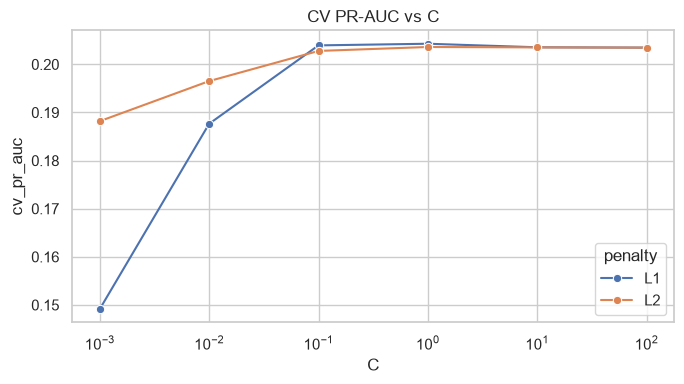

In [6]:
plt.figure(figsize=(7, 4))
plot_df = results.rename(columns={"l1_ratio (0=L2, 1=L1)": "penalty"}); plot_df["penalty"] = plot_df["penalty"].map({0.0: "L2", 1.0: "L1"})
sns.lineplot(data=plot_df, x="C", y="cv_pr_auc", hue="penalty", marker="o"); plt.xscale("log")
plt.title("CV PR-AUC vs C"); save_fig("tuning_curve"); plt.show()

### Insight -> decision (tuned vs baseline)

*(Fill in with your own numbers.)*

- Finding: 
- Decision: 
- Reason / alternative rejected: 

## 5. Threshold tuning (my optimisation topic)

The cut-off is chosen on **out-of-fold predictions of the training set** (never on the test set). Two candidates: (a) the threshold that maximises F1, (b) the threshold that fits a call budget (call only the top 20% of the ranked list).

Best-F1 threshold : 0.732  (precision 0.297, recall 0.251, F1 0.272)
Budget threshold  : 0.535  (top 20% of training clients)


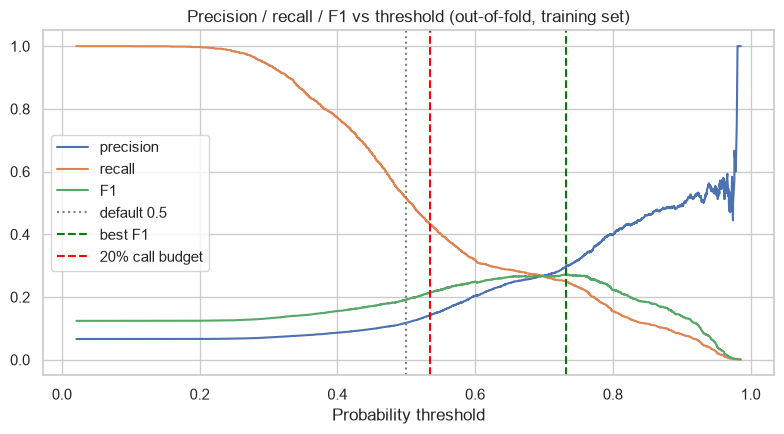

In [7]:
oof = cross_val_predict(best, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof)
f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
i_best = int(np.argmax(f1[:-1]))
thr_f1 = float(thr[i_best])

CALL_BUDGET = 0.20                                   # call 20% of clients
thr_budget = float(np.quantile(oof, 1 - CALL_BUDGET))

print(f"Best-F1 threshold : {thr_f1:.3f}  (precision {prec[i_best]:.3f}, recall {rec[i_best]:.3f}, F1 {f1[i_best]:.3f})")
print(f"Budget threshold  : {thr_budget:.3f}  (top {CALL_BUDGET:.0%} of training clients)")

plt.figure(figsize=(8, 4.5))
plt.plot(thr, prec[:-1], label="precision"); plt.plot(thr, rec[:-1], label="recall"); plt.plot(thr, f1[:-1], label="F1")
plt.axvline(0.5, color="grey", ls=":", label="default 0.5")
plt.axvline(thr_f1, color="green", ls="--", label="best F1"); plt.axvline(thr_budget, color="red", ls="--", label="20% call budget")
plt.xlabel("Probability threshold"); plt.title("Precision / recall / F1 vs threshold (out-of-fold, training set)")
plt.legend(); save_fig("threshold_tradeoff"); plt.show()

### Insight -> decision (which threshold and why)

*(Fill in with your own numbers.)*

- Finding: 
- Decision: 
- Reason / alternative rejected: 

## 6. Final evaluation on the untouched test set (used once)

In [8]:
def test_metrics(model, threshold=0.5):
    p = model.predict_proba(X_test)[:, 1]
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {"threshold": threshold, "called_%": pred.mean() * 100,
            "precision": precision_score(y_test, pred, zero_division=0), "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred), "TP": tp, "FP": fp, "FN": fn, "TN": tn}


baseline.fit(X_train, y_train)               # baseline is refit on the full training part
p_base = baseline.predict_proba(X_test)[:, 1]; p_best = best.predict_proba(X_test)[:, 1]

summary = pd.DataFrame({
    "PR-AUC":  [average_precision_score(y_test, p_base), average_precision_score(y_test, p_best)],
    "ROC-AUC": [roc_auc_score(y_test, p_base), roc_auc_score(y_test, p_best)],
}, index=["baseline", "tuned"])
print(summary)

thr_table = pd.DataFrame([test_metrics(best, 0.5), test_metrics(best, thr_f1), test_metrics(best, thr_budget)],
                         index=["default 0.5", "best-F1", "20% budget"])
print("\nTuned model at different thresholds (test set):")
print(thr_table)
print(f"\nTest yes-rate is {y_test.mean():.2%} vs {y_train.mean():.2%} in train -> the class balance shifts over time.")

          PR-AUC  ROC-AUC
baseline  0.5070   0.6905
tuned     0.4539   0.6487

Tuned model at different thresholds (test set):
             threshold  called_%  precision  recall     f1    TP    FP    FN  \
default 0.5     0.5000   70.2449     0.3672  0.8087 0.5051  2033  3503   481   
best-F1         0.7316   40.8324     0.4590  0.5875 0.5154  1477  1741  1037   
20% budget      0.5351   63.5072     0.3894  0.7753 0.5184  1949  3056   565   

               TN  
default 0.5  1864  
best-F1      3626  
20% budget   2311  

Test yes-rate is 31.90% vs 6.61% in train -> the class balance shifts over time.


### Insight -> decision (test results)

*(Fill in with your own numbers.)*

- Finding: 
- Decision: 
- Reason / alternative rejected: 

## 7. Business view: cumulative gain and lift (test set)

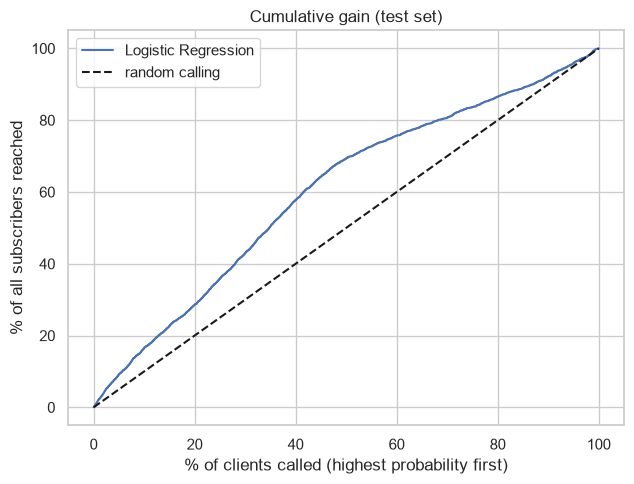

Calling the top 10% of clients reaches 16.5% of all subscribers (lift 1.65x)
Calling the top 20% of clients reaches 28.6% of all subscribers (lift 1.43x)
Calling the top 30% of clients reaches 43.0% of all subscribers (lift 1.43x)


In [9]:
order = np.argsort(-p_best)
hits = y_test.values[order]
share_called = np.arange(1, len(hits) + 1) / len(hits)
share_found = np.cumsum(hits) / hits.sum()

plt.figure(figsize=(6.5, 5))
plt.plot(share_called * 100, share_found * 100, label="Logistic Regression")
plt.plot([0, 100], [0, 100], "k--", label="random calling")
plt.xlabel("% of clients called (highest probability first)"); plt.ylabel("% of all subscribers reached")
plt.title("Cumulative gain (test set)"); plt.legend(); save_fig("gain_chart"); plt.show()

for frac in (0.10, 0.20, 0.30):
    k = int(len(hits) * frac)
    print(f"Calling the top {frac:.0%} of clients reaches {hits[:k].sum() / hits.sum():.1%} of all subscribers "
          f"(lift {hits[:k].sum() / hits.sum() / frac:.2f}x)")

### Insight -> decision (business message)

*(Fill in with your own numbers.)*

- Finding: 
- Decision: 
- Reason / alternative rejected: 

## 8. Interpretation: odds ratios

Strongest NEGATIVE effects (lower chance of subscribing):
                          coef  odds_ratio
num__emp.var.rate      -2.0116      0.1338
cat__month_nov         -1.7895      0.1670
cat__month_may         -0.7073      0.4930
cat__contact_telephone -0.3997      0.6705
num__nr.employed       -0.2439      0.7836
cat__loan_unknown      -0.2317      0.7932
num__cons.conf.idx     -0.2157      0.8060
cat__age_group_35-44   -0.2137      0.8076

Strongest POSITIVE effects (higher chance of subscribing):
                            coef  odds_ratio
num__euribor3m            2.0531      7.7923
cat__age_group_65+        0.6841      1.9821
cat__month_oct            0.6776      1.9692
cat__month_mar            0.6047      1.8306
cat__poutcome_nonexistent 0.5045      1.6561
cat__job_student          0.4610      1.5857
cat__education_illiterate 0.3976      1.4882
cat__job_retired          0.3378      1.4019

Note: numeric features are standardised, so their odds ratios are per 1 standard deviatio

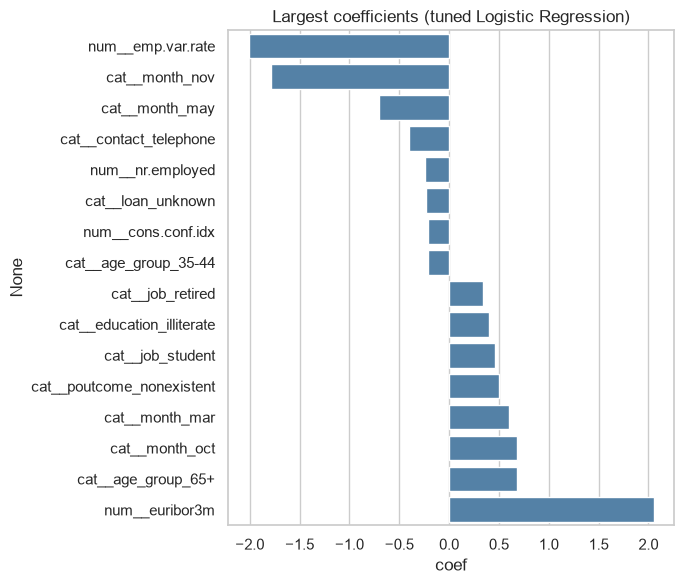

In [10]:
names = best.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(best.named_steps["clf"].coef_[0], index=names)
odds = pd.DataFrame({"coef": coefs, "odds_ratio": np.exp(coefs)}).sort_values("coef")
print("Strongest NEGATIVE effects (lower chance of subscribing):"); print(odds.head(8))
print("\nStrongest POSITIVE effects (higher chance of subscribing):"); print(odds.tail(8).iloc[::-1])
print("\nNote: numeric features are standardised, so their odds ratios are per 1 standard deviation.")

top = pd.concat([odds.head(8), odds.tail(8)])
plt.figure(figsize=(7, 6)); sns.barplot(x=top["coef"], y=top.index, color="steelblue")
plt.title("Largest coefficients (tuned Logistic Regression)"); save_fig("coefficients"); plt.show()

### Insight -> decision (what the bank should know)

*(Fill in with your own numbers.)*

- Finding: 
- Decision: 
- Reason / alternative rejected: 

## 9. Log the runs and save the tuned model

*Run this cell once - it appends rows to `results/experiment_log.csv`.*

In [11]:
HEADER = ["model", "params", "cv_pr_auc", "test_pr_auc", "test_roc_auc", "recall", "precision", "f1", "notes"]


def log_row(row):
    new_file = (not EXPERIMENT_LOG.exists()) or EXPERIMENT_LOG.stat().st_size == 0
    with open(EXPERIMENT_LOG, "a", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        if new_file:
            w.writerow(HEADER)
        w.writerow(row)


base05 = test_metrics(baseline, 0.5); tuned05 = test_metrics(best, 0.5)
log_row(["LogisticRegression (baseline)", "C=1;l2;class_weight=balanced", round(base_cv["pr_auc"][0], 4),
         round(summary.loc["baseline", "PR-AUC"], 4), round(summary.loc["baseline", "ROC-AUC"], 4),
         round(base05["recall"], 4), round(base05["precision"], 4), round(base05["f1"], 4), "Member 1; threshold 0.5"])
log_row(["LogisticRegression (tuned)", str(grid.best_params_).replace(",", ";"), round(grid.best_score_, 4),
         round(summary.loc["tuned", "PR-AUC"], 4), round(summary.loc["tuned", "ROC-AUC"], 4),
         round(tuned05["recall"], 4), round(tuned05["precision"], 4), round(tuned05["f1"], 4),
         f"Member 1; threshold 0.5; best-F1 thr {thr_f1:.3f}; 20% budget thr {thr_budget:.3f}"])

joblib.dump(best, MODEL_DIR / "lr_tuned.joblib")
joblib.dump({"thr_f1": thr_f1, "thr_budget": thr_budget}, MODEL_DIR / "lr_thresholds.joblib")
print("Logged 2 rows and saved models/experiments/lr_tuned.joblib")

Logged 2 rows and saved models/experiments/lr_tuned.joblib


## 10. Summary for the report and viva

| Item | Result |
|---|---|
| Baseline CV PR-AUC | |
| Tuned CV PR-AUC | |
| Test PR-AUC (tuned) | |
| Chosen threshold and why | |
| Top 20% of clients reach ...% of subscribers | |
| 3 strongest drivers of subscription | |